In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())


2.10.0+cu128
True


In [2]:
import numpy as np
import matplotlib as plt


In [3]:
from poisson_disk import poisson_disk_sampling_grid, poisson_disk_sampling, visualize_poisson_disk_samples
from spectra import visualize_sampling_analysis, visualize_zone_plate, visualize_sampling_analysis_gpu
from void_and_cluster import void_and_cluster, visualize_void_and_cluster_noise, void_cluster_to_points
from void_and_cluster_gpu import void_and_cluster_gpu, void_and_cluster_to_numpy, void_cluster_to_points_gpu

In [3]:
(width, height) = (256, 256)
min_radius = 4

c:\Users\ville\Desktop\BlueNoisePointProcesses\python\spectra.py:259: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


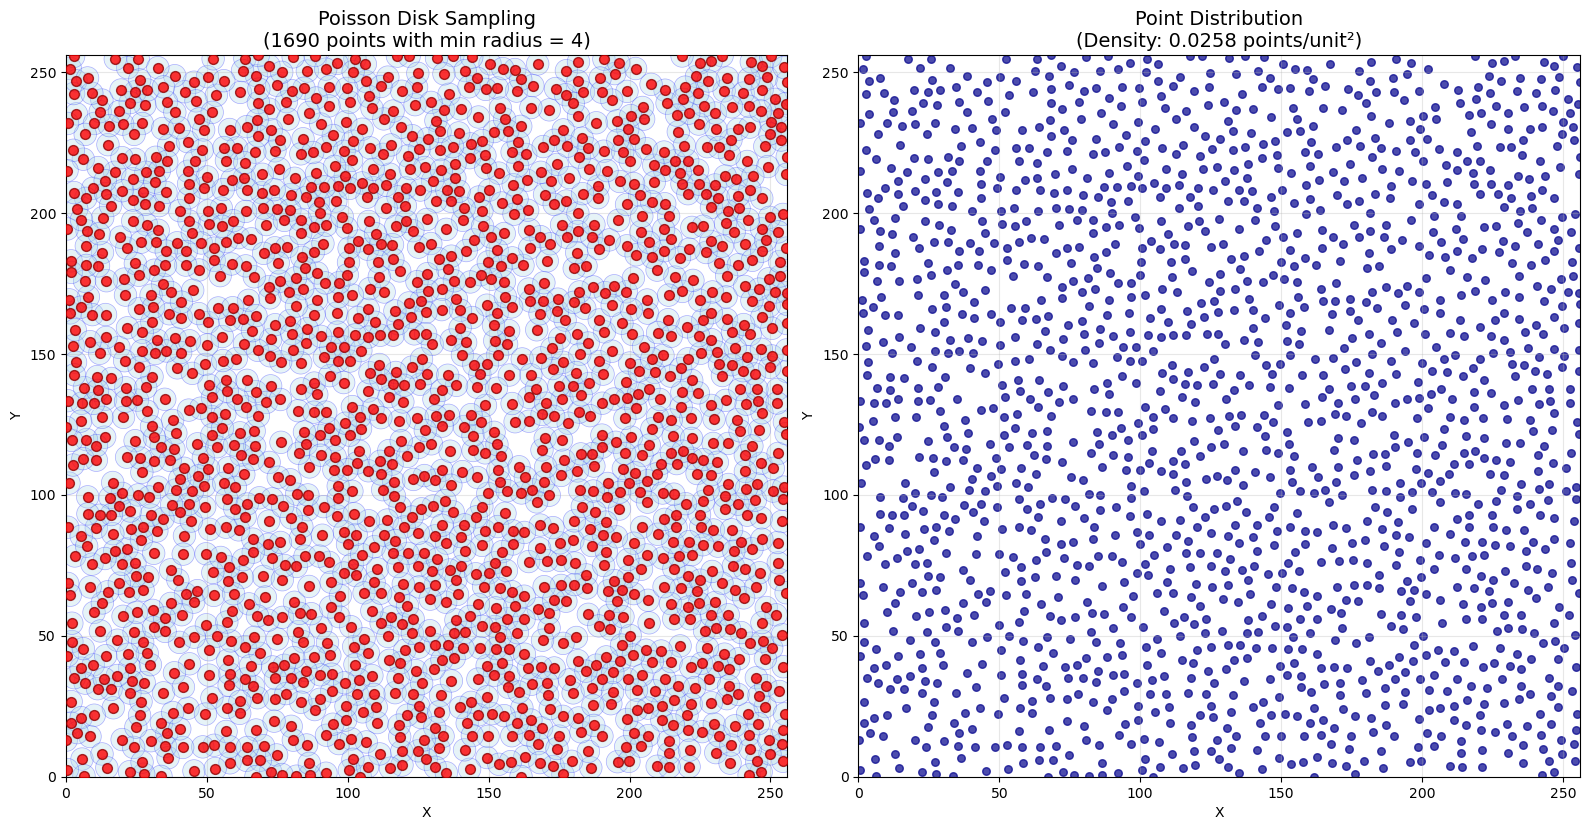

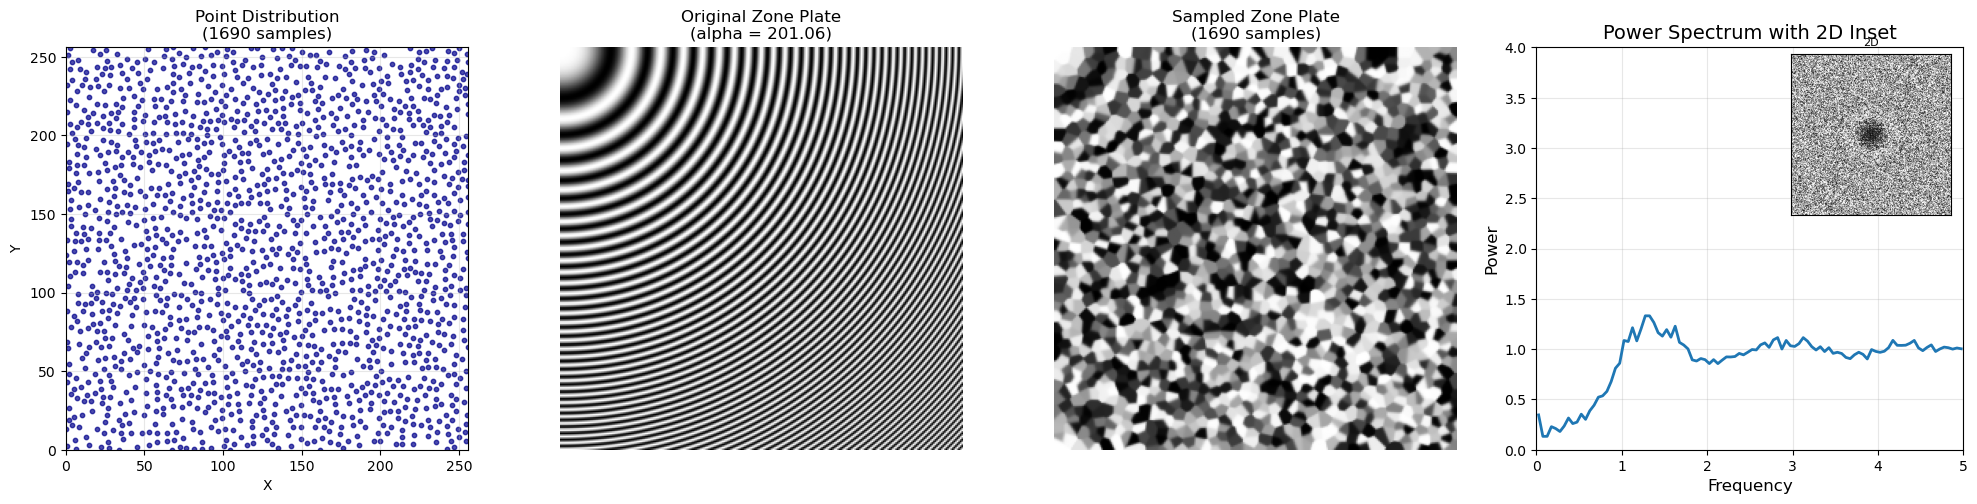

In [4]:

#points = poisson_disk_sampling_grid((width, height), min_radius, max_attempts = 30 , seed = 12)
points = poisson_disk_sampling((width, height), min_radius, max_attempts = 30 , seed = 12)
poisson_samples_visualized = visualize_poisson_disk_samples((width, height), min_radius, points)
poisson_zone_plate = visualize_sampling_analysis(points, domain_size = (width, height), zone_plate_alpha = np.pi * 64.0, kernel_radius = 1.5)
#zone_plate = visualize_zone_plate(alpha = np.pi * 64)



Step 1: Generating initial binary pattern...
Initial pattern converged after 2113 iterations
Step 2: Assigning ranks by removing clusters...
Step 3: Adding points until half full...
Step 4: Adding remaining points...


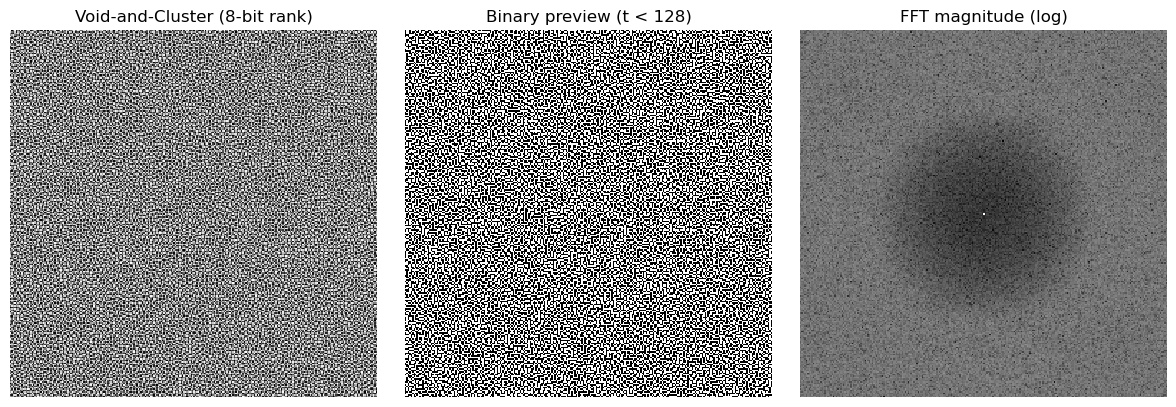

c:\Users\ville\Desktop\BlueNoisePointProcesses\python\spectra.py:323: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


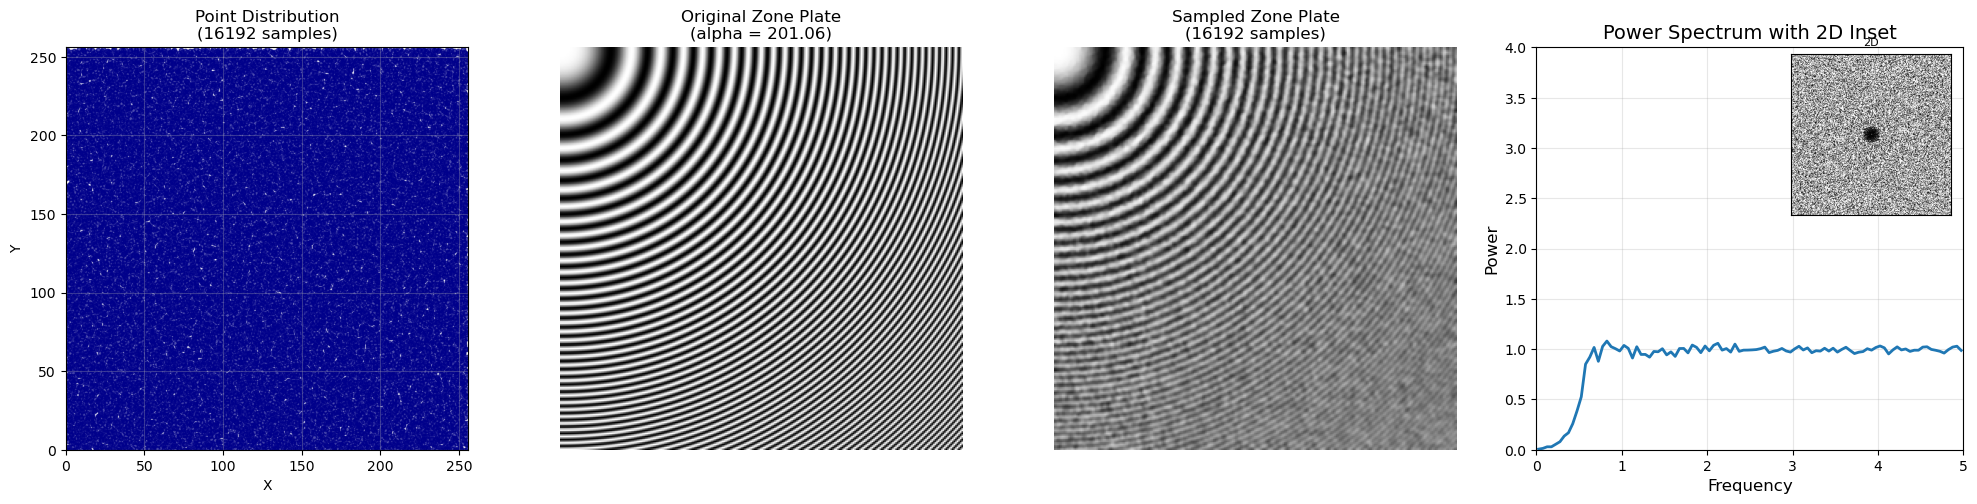

In [4]:
(width, height) = (256, 256)

void_and_cluster_points = void_and_cluster((width, height), 1.9)
void_and_cluster_to_points = void_cluster_to_points(void_and_cluster_points, (width * height / 4))
visualize_void_and_cluster_noise(void_and_cluster_points, threshold = 128, filename = "void_and_cluster_example.png")
poisson_zone_plate = visualize_sampling_analysis(void_and_cluster_to_points, domain_size = (width, height), zone_plate_alpha = np.pi * 64.0, kernel_radius = 1.1)


Step 1: Generating initial binary pattern...
Initial pattern converged after 2150 iterations
Step 2: Assigning ranks by removing clusters...
Step 3: Adding points until half full...
Step 4: Adding remaining points...


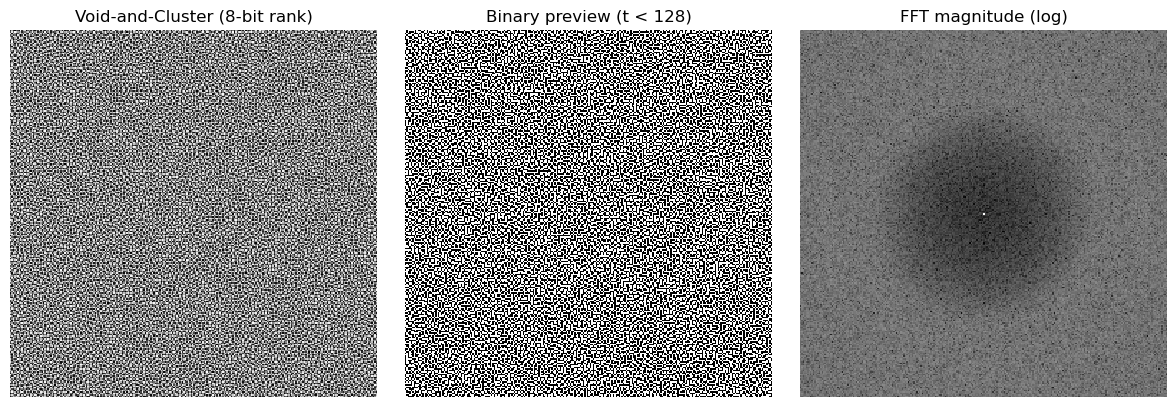

OutOfMemoryError: CUDA out of memory. Tried to allocate 12.42 GiB. GPU 0 has a total capacity of 11.94 GiB of which 0 bytes is free. Of the allocated memory 12.42 GiB is allocated by PyTorch, and 12.43 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

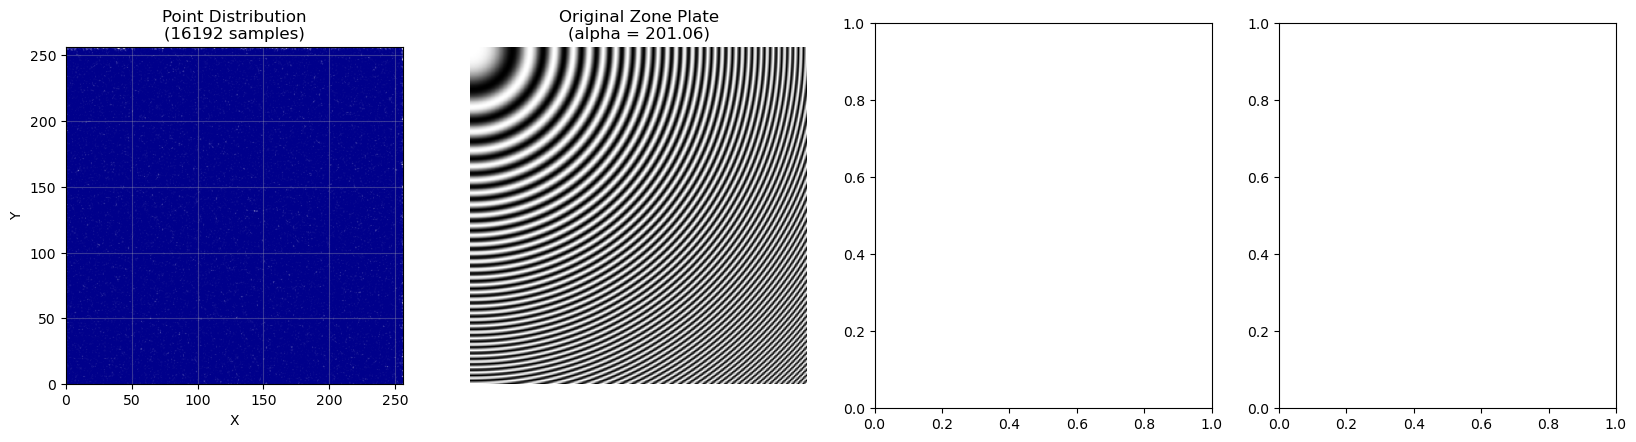

In [ ]:
(width, height) = (256, 256)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

void_and_cluster_points = void_and_cluster_gpu((width, height), sigma = 1.9, device = device)
void_and_cluster_to_points = void_cluster_to_points_gpu(void_and_cluster_points, (width * height / 4))
visualize_void_and_cluster_noise(void_and_cluster_points.cpu().numpy(), threshold = 128, filename = "void_and_cluster_example.png")
# Need to use a small batch size for gpu memory
poisson_zone_plate = visualize_sampling_analysis_gpu(void_and_cluster_to_points, domain_size = (width, height), zone_plate_alpha = np.pi * 64.0, kernel_radius = 1.1, device = device, batch_size = 16)